# Key Efficiencies Comparison (Constant $V_\text{mod}$, bounded $g$, $m = 1$)

This is the notebook to benchmark MD, SR and TPT, all over transmission distance. The asymptotic key rates are found as follows, where $m \geq 1$ is a free parameter for TPT and SR.

$$
K_\infty^\text{SR} = H(S_{1,\ldots,m}(X)) - \sum_{i \in m} h(e_\text{i, SR}) - \chi_{EB}
$$

$$
K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
$$

$$
K_\infty^\text{TPT} = p_\text{pass}(H(T(X)) - h(e_\text{TPT}) - \chi_{EB}
$$

Therefore, to plot these, we need to optimise each of the above key rates over $V_\text{mod}$ for a given $T(d) = 10^{-(\alpha d)/10}$ where $\alpha$ is the fibre loss coefficient, which we will say is 0.2 dB/km. For rigor, the optimisation problem becomes
$$
\max_{V_{\mathrm{mod}},\,\{\tau_i\}_{i=1}^M,\,\{g_{j,-},g_{j,+}\}_{j=-M}^M}
K_{\infty,\mathrm{TPT}}\Bigl(
    V_{\mathrm{mod}},\;
    \{\tau_{-M},\dots,\tau_{-1},0,\tau_{1},\dots,\tau_{M}\},\;
    \{g_{j,-},g_{j,+}\}_{j=-M}^M
    \;;\;T,\xi
\Bigr)
$$
where $g_{i,\pm} = 0 \;\; \forall i$ in the case of SR.

In [1]:
import numpy as np
import importlib
from tqdm import tqdm
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from scipy.special import erfc  
import matplotlib.pyplot as plt

from guard_band_postselection import GBSR
importlib.reload(GBSR)

print("Libraries imported.")

Libraries imported.


In [2]:
# Global variables and functions
distances = np.linspace(0.001, 100, 200)

# DO NOT CHANGE THESE VALUES (I've got them nice for a plot)

fibre_loss_coeff = 0.2 # In dB/km
excess_noise = 0.005

_lambda = True
Delta_QCT = 0.12

def T_from_d(d):
    # T(d) = 10^{-(\alpha d)/10}
    return np.power(10.0, -(fibre_loss_coeff * d) / 10.0)

## SR

In [3]:
"""
m = 1

DW_key_rates = []
Is = []
chis = []

SR_m1_key_rates = []
SR_m1_error_rates = []
SR_m1_leaked_informations = []

tau_arr = [-np.inf, 0.0, np.inf]
g_arr = [
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0]
]

for d in distances:
    transmittance = T_from_d(d)

    sr = GBSR.SR(m, SR_v_mod, transmittance, excess_noise, _lambda, Delta_QCT)

    error_rate = sr._evaluate_slice_error_rates(tau_arr, g_arr)[0]
    key_rate = sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)

    SR_m1_error_rates.append(error_rate)
    SR_m1_key_rates.append(key_rate)

    DW_key_rates.append(sr.I_AB - sr.gaussian_attack_holevo_information)
    Is.append(sr.I_AB)
    chis.append(sr.gaussian_attack_holevo_information)
"""

# m1
m = 1

sr = GBSR.SR(m, 1.0, 1.0, 0.0, _lambda = True)

DW_key_rates = []
Is = []
chis = []

SR_m1_key_rates = []
SR_m1_error_rates = []
SR_m1_v_mods = []
SR_m1_leaked_informations = []

tau_arr = [-np.inf, 0.0, np.inf]
g_arr = [
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0]
]

for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Optimise v_mod for this distance
    def v_mod_objective_function(v_mod):
        sr.__init__(m, v_mod, transmittance, excess_noise, _lambda = True)

        return -1.0 * sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)
    
    optimisation_return = minimize_scalar(v_mod_objective_function, bounds=(0.5, 10.0), method='bounded')

    SR_m1_v_mods.append(optimisation_return.x)
    SR_m1_key_rates.append(-1.0 * optimisation_return.fun)

    # Set optimal gbsr
    sr.__init__(m, SR_m1_v_mods[-1], transmittance, excess_noise, _lambda = True)
    error_rates = sr._evaluate_slice_error_rates(tau_arr, g_arr)
    SR_m1_error_rates.append(error_rates)
    SR_m1_leaked_informations.append(sr._evaluate_leaked_information())

    DW_key_rates.append(sr.devetak_winter)
    Is.append(sr.I_AB)
    chis.append(sr.gaussian_attack_holevo_information)

100%|██████████| 200/200 [00:23<00:00,  8.59it/s]


## TPT

In [4]:

m = 1

gbsr = GBSR.GBSR(m, 1.0, 1.0, 0.0, _lambda, Delta_QCT)

TPT_m1_key_rates = []
TPT_m1_error_rates = []
TPT_m1_v_mods = []
TPT_m1_gs = []
TPT_m1_leaked_informations = []
TPT_m1_p_passes = []

tau_arr = [-np.inf, 0.0, np.inf]

def TPT_m1_objective_function(params, args):
    v_mod, g = params
    transmittance = args

    gbsr.__init__(m, v_mod, transmittance, excess_noise, _lambda, Delta_QCT)    

    g_arr = [
        [0.0, 0.0],
        [g, g],
        [0.0, 0.0]
    ]

    return -1.0 * gbsr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)


for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Perform optimisation
    initial_guesss = [
        1.0, # v_mod
        0.1 # g
    ]

    bounds = [
        (0.5, 1.5), # v_mod
        (0.0, 5.0)
    ]

    optimisation_return = minimize(TPT_m1_objective_function, initial_guesss, args=(transmittance,), bounds=bounds)

    optimal_v_mod, optimal_g = optimisation_return.x
    g_arr = [
        [0.0, 0.0],
        [optimal_g, optimal_g],
        [0.0, 0.0]
    ]

    gbsr.__init__(m, optimal_v_mod, transmittance, excess_noise, _lambda, Delta_QCT)

    error_rate = gbsr.evaluate_error_rate(tau_arr, g_arr)
    TPT_m1_error_rates.append(error_rate)
    TPT_m1_key_rates.append(-1.0 * optimisation_return.fun)
    TPT_m1_v_mods.append(optimal_v_mod)
    TPT_m1_gs.append(optimal_g)
    TPT_m1_leaked_informations.append(gbsr._evaluate_leaked_information(error_rate))
    TPT_m1_p_passes.append(gbsr.evaluate_p_pass(tau_arr, g_arr))


100%|██████████| 200/200 [00:24<00:00,  8.07it/s]


## MD

In [5]:
gbsr = GBSR.GBSR(1, 1.0, 1.0, 0.0, _lambda = _lambda)

MD_key_rates = []
MD_v_mods = []
MD_leaked_informations = []

# This has been checked against Jouguet-2011 table 1 for correctness
def C_biawgn(SNR):
    if SNR <= 0:
        return 0.0
    def integrand(z):
        pdf = norm.pdf(z)
        log2t = np.log1p(np.exp(-2*np.sqrt(SNR)*z - 2*SNR)) / np.log(2)
        return pdf * log2t
    res, _ = quad(integrand, -10, 10, epsabs=1e-10, epsrel=1e-10)
    return 1 - res

# def MD_lambda_model(distance):
#     if distance < 0:
#         distance = 0
#     # Use an exponential approach: beta = 0.95 - A * exp(-k * distance)
#     # Choose A = 0.35 (0.95 - 0.6) and set k to make it close to 0.95 at 30 km
#     A = 0.1
#     k = np.log(A / 0.01) / 30  # Ensure beta is within 0.01 of 0.95 by 30 km
#     beta = 0.999 - A * np.exp(-k * distance)
#     return (1.0 / beta) - 1.0


def MD_objective_function(variables, transmittance, d):
    # K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
    (v_mod,) = variables

    # Only used to calculate Holevo information in this case.
    gbsr.__init__(1, v_mod, transmittance, excess_noise, _lambda, Delta_QCT)

    # Evaluate key rate terms
    bits_sent = 1.0
    leaked_information = (1.0 + 0.001) * (1.0 - C_biawgn(gbsr.SNR))
    holevo_information = gbsr.gaussian_attack_holevo_information

    # Key rate
    K = bits_sent - leaked_information - holevo_information

    return -1.0 * K

for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Optimise v_mod
    optimisation_return = minimize(
        MD_objective_function,
        (0.5,),
        args=(transmittance, d),
        bounds = [(1.0, 3.0)],
    )

    # Unpack optimisation return for plotting
    MD_v_mods.append(optimisation_return.x[0])
    MD_key_rates.append(-optimisation_return.fun)

    # Initialize gbsr with the optimal v_mod and transmittance
    gbsr.__init__(1, optimisation_return.x[0], transmittance, excess_noise, _lambda, Delta_QCT)
    
    # Append the leaked information using the SNR from the initialized gbsr
    MD_leaked_informations.append(C_biawgn(gbsr.SNR))

100%|██████████| 200/200 [01:13<00:00,  2.74it/s]


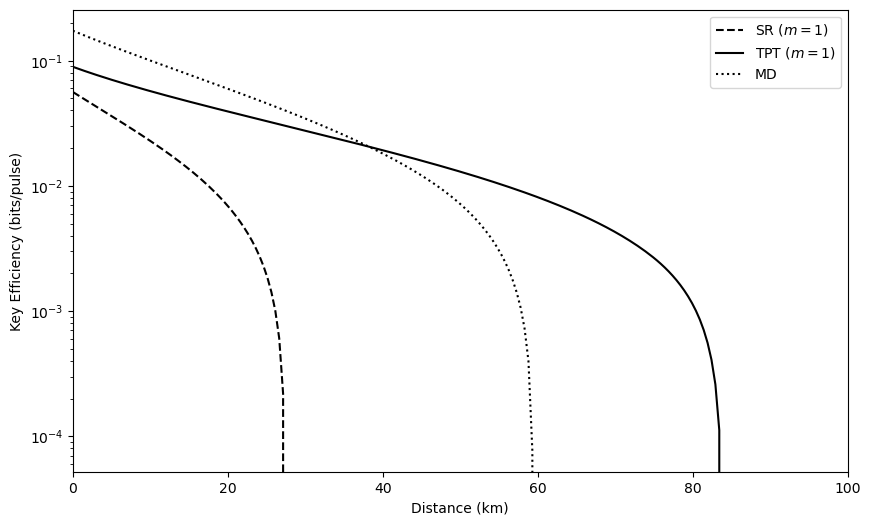

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(distances, SR_m1_key_rates, label=r"SR ($m = 1$)", linestyle='--', color = "black")
plt.plot(distances, TPT_m1_key_rates, label=r"TPT ($m = 1$)", linestyle='-', color = "black")
# plt.plot(distances, DW_key_rates, label="DW Key Rate", marker='s')
plt.plot(distances, MD_key_rates, label="MD", linestyle=':', color = "black")
plt.xlabel("Distance (km)")
plt.ylabel("Key Efficiency (bits/pulse)")
plt.yscale('log')
plt.xlim(0, 100)
plt.legend()
# plt.grid(True)
plt.show()

In [7]:
import pandas as pd

# Create a DataFrame with the required data
data = {
    "distances": [f"{d:.8f}" for d in distances],
    "SR_m1_key_rates": [f"{rate:.8f}" for rate in SR_m1_key_rates],
    "TPT_m1_key_rates": [f"{rate:.8f}" for rate in TPT_m1_key_rates],
    "MD_key_rates": [f"{rate:.8f}" for rate in MD_key_rates]
}

df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv("key_rates.csv", index=False)
print("Data exported to key_rates.csv")

Data exported to key_rates.csv


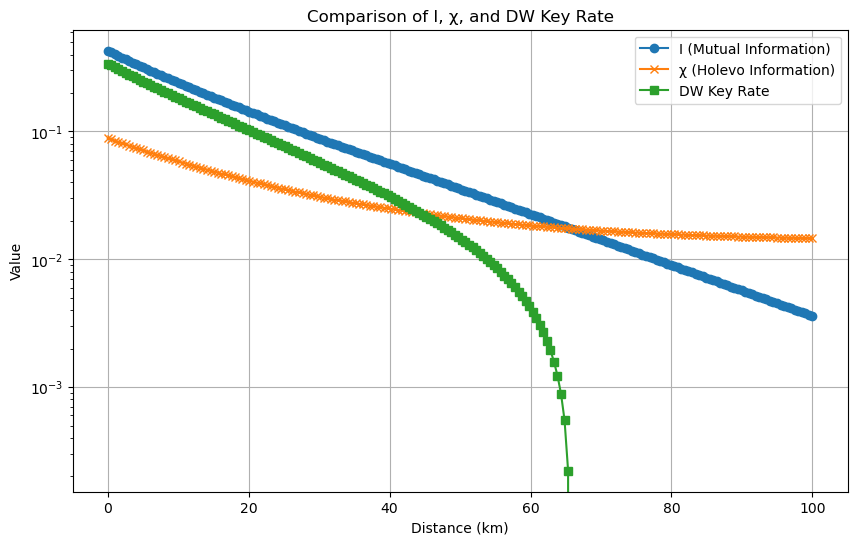

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(distances, Is, label="I (Mutual Information)", marker='o')
plt.plot(distances, chis, label="χ (Holevo Information)", marker='x')
plt.plot(distances, DW_key_rates, label="DW Key Rate", marker='s')
plt.xlabel("Distance (km)")
plt.ylabel("Value")
plt.title("Comparison of I, χ, and DW Key Rate")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

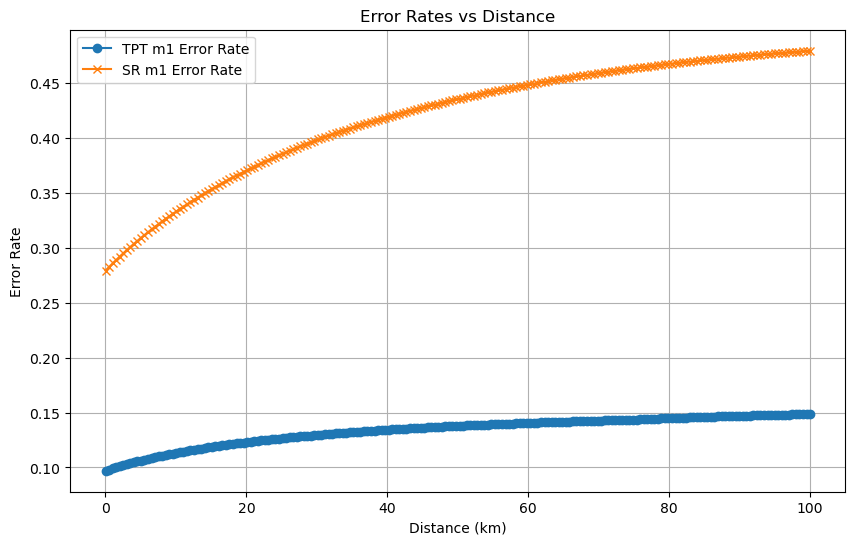

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(distances, TPT_m1_error_rates, label="TPT m1 Error Rate", marker='o')
plt.plot(distances, SR_m1_error_rates, label="SR m1 Error Rate", marker='x')
plt.xlabel("Distance (km)")
plt.ylabel("Error Rate")
plt.title("Error Rates vs Distance")
plt.grid(True)
plt.legend()
plt.show()

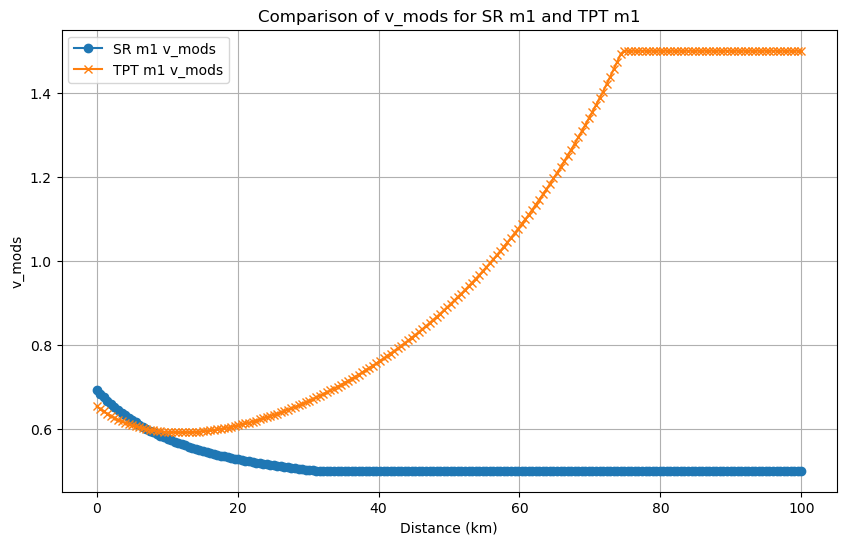

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(distances, SR_m1_v_mods, label="SR m1 v_mods", marker='o')
plt.plot(distances, TPT_m1_v_mods, label="TPT m1 v_mods", marker='x')
plt.xlabel("Distance (km)")
plt.ylabel("v_mods")
plt.title("Comparison of v_mods for SR m1 and TPT m1")
plt.legend()
plt.grid(True)
plt.show()

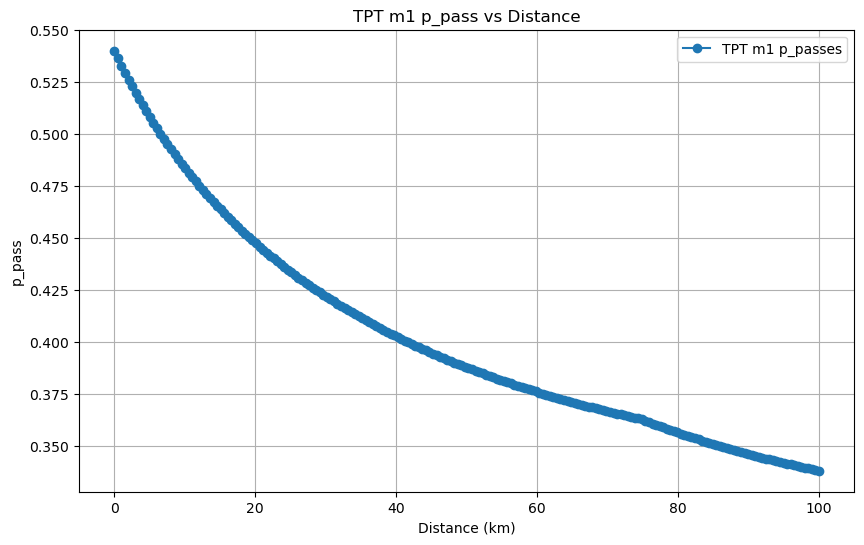

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(distances, TPT_m1_p_passes[:len(distances)], label="TPT m1 p_passes", marker='o')
plt.xlabel("Distance (km)")
plt.ylabel("p_pass")
plt.title("TPT m1 p_pass vs Distance")
plt.grid(True)
plt.legend()
plt.show()